In [375]:

from lseg.modules.models.lseg_net import LSegEncNet
import numpy as np
import os
import torch
import cv2
import clip
import torchvision.transforms as transforms
from lseg.additional_utils.models import resize_image, pad_image, crop_image

In [376]:

# The camera intrinsic matrix
# obtained by echoing the /camera/camera_info topic in ROS
cam_mat = np.array([
    [528.43,   0.,   320.  ],
    [  0.,   528.43, 240.  ],
    [  0.,     0.,     1.  ]
])
cam_mat_inv = np.linalg.inv(cam_mat)

def scale_cam_mat(cam_mat, scale_x, scale_y):
    scaled_cam_mat = cam_mat.copy()
    scaled_cam_mat[0, 0] *= scale_x
    scaled_cam_mat[1, 1] *= scale_y
    scaled_cam_mat[0, 2] *= scale_x
    scaled_cam_mat[1, 2] *= scale_y
    return scaled_cam_mat
# Fixed rotation: camera optical → camera_link (standard ROS convention)
# optical:     x right,   y down,    z forward
# camera_link: x forward, y left,    z up
R_optical_to_link = np.array([
    [ 0,  0,  1],   # x_link  =  z_optical  (forward)
    [-1,  0,  0],   # y_link  = -x_optical  (left)
    [ 0, -1,  0],   # z_link  = -y_optical  (up)
])

In [377]:
crop_size = 480 # 480
base_size = 520 # 520
lang = "sofa,person,rug,curtain,lamp,table,shoe,other"
labels = lang.split(",")

# loading models
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
clip_version = "ViT-B/32"
clip_feat_dim = {'RN50': 1024, 'RN101': 512, 'RN50x4': 640, 'RN50x16': 768,
                'RN50x64': 1024, 'ViT-B/32': 512, 'ViT-B/16': 512, 'ViT-L/14': 768}[clip_version]
print("Loading CLIP model...")
clip_model, preprocess = clip.load(clip_version)  # clip.available_models()
clip_model.to(device).eval()
lang_token = clip.tokenize(labels)
lang_token = lang_token.to(device)
with torch.no_grad():
    text_feats = clip_model.encode_text(lang_token)
    text_feats = text_feats / text_feats.norm(dim=-1, keepdim=True)
text_feats = text_feats.cpu().numpy()
print('text_feats shape:', text_feats.shape)

cuda
Loading CLIP model...
text_feats shape: (8, 512)


In [378]:
def get_lseg_feat(model: LSegEncNet, image: np.array, labels, transform, crop_size=480, \
                 base_size=520, norm_mean=[0.5, 0.5, 0.5], norm_std=[0.5, 0.5, 0.5], device='cpu'):
    # vis_image = image.copy()
    image = transform(image).unsqueeze(0).to(device)
    img = image[0].permute(1,2,0)
    img = img * 0.5 + 0.5
    
    batch, _, h, w = image.size()
    stride_rate = 2.0/3.0
    stride = int(crop_size * stride_rate)

    long_size = base_size
    if h > w:
        height = long_size
        width = int(1.0 * w * long_size / h + 0.5)
        short_size = width
    else:
        width = long_size
        height = int(1.0 * h * long_size / w + 0.5)
        short_size = height


    cur_img = resize_image(image, height, width, **{'mode': 'bilinear', 'align_corners': True}).to(device)

    if long_size <= crop_size:
        pad_img = pad_image(cur_img, norm_mean,
                            norm_std, crop_size)
        print(pad_img.shape)
        with torch.no_grad():
            outputs, logits = model(pad_img, labels)
        outputs = crop_image(outputs, 0, height, 0, width)
    else:
        if short_size < crop_size:
            # pad if needed
            pad_img = pad_image(cur_img, norm_mean,
                                norm_std, crop_size)
        else:
            pad_img = cur_img
        _,_,ph,pw = pad_img.shape #.size()
        assert(ph >= height and pw >= width)
        h_grids = int(math.ceil(1.0 * (ph-crop_size)/stride)) + 1
        w_grids = int(math.ceil(1.0 * (pw-crop_size)/stride)) + 1
        with torch.no_grad():
            outputs = torch.zeros(batch, model.out_c, ph, pw, device=device)
            logits_outputs = torch.zeros(batch, len(labels), ph, pw, device=device)
            count_norm = torch.zeros(batch, 1, ph, pw, device=device)
        # grid evaluation
        for idh in range(h_grids):
            for idw in range(w_grids):
                h0 = idh * stride
                w0 = idw * stride
                h1 = min(h0 + crop_size, ph)
                w1 = min(w0 + crop_size, pw)
                crop_img = crop_image(pad_img, h0, h1, w0, w1)
                # pad if needed
                pad_crop_img = pad_image(crop_img, norm_mean,
                                            norm_std, crop_size)
                with torch.no_grad():
                    output, logits = model(pad_crop_img, labels)
                cropped = crop_image(output, 0, h1-h0, 0, w1-w0)
                cropped_logits = crop_image(logits, 0, h1-h0, 0, w1-w0)
                outputs[:,:,h0:h1,w0:w1] += cropped
                logits_outputs[:,:,h0:h1,w0:w1] += cropped_logits
                count_norm[:,:,h0:h1,w0:w1] += 1
        assert((count_norm==0).sum()==0)
        outputs = outputs / count_norm
        logits_outputs = logits_outputs / count_norm
        outputs = outputs[:,:,:height,:width]
        logits_outputs = logits_outputs[:,:,:height,:width]
    outputs = outputs.to(device)
    outputs = outputs.cpu().numpy() # B, D, H, W
    predicts = [torch.max(logit, 0)[1].cpu().numpy() for logit in logits_outputs]
    pred = predicts[0]

    return outputs, logits_outputs

In [379]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
    ]
)

model = LSegEncNet(lang, arch_option=0,
                    block_depth=0,
                    activation='lrelu',
                    crop_size=crop_size)
model_state_dict = model.state_dict()
pretrained_state_dict = torch.load("lseg/checkpoints/demo_e200.ckpt", map_location=torch.device(device), weights_only=False)
pretrained_state_dict = {k.lstrip('net.'): v for k, v in pretrained_state_dict['state_dict'].items()}
model_state_dict.update(pretrained_state_dict)
model.load_state_dict(pretrained_state_dict)
model.eval()
model = model.to(device)



In [380]:
from utils.clip_mapping_utils import depth2pc_gazebo, save_map, pos2grid_id, project_point,transform_pc, load_pose
import tqdm
gs = 150
cs = 0.05
depth_sample_rate = 70

data_dir = "/tmp/vlmap_recording/test7/"
rgb_dir = os.path.join(data_dir, "rgb")
depth_dir = os.path.join(data_dir, "depth")
pose_dir = os.path.join(data_dir, "pose")

rgb_list = sorted(os.listdir(rgb_dir), key=lambda x: int(
    x.split("_")[-1].split(".")[0]))
depth_list = sorted(os.listdir(depth_dir), key=lambda x: int(
    x.split("_")[-1].split(".")[0]))
pose_list = sorted(os.listdir(pose_dir), key=lambda x: int(
    x.split("_")[-1].split(".")[0]))
pose_list = sorted(os.listdir(pose_dir), key=lambda x: int(
    x.split("_")[-1].split(".")[0]))

rgb_list = [os.path.join(rgb_dir, x) for x in rgb_list]
depth_list = [os.path.join(depth_dir, x) for x in depth_list]
pose_list = [os.path.join(pose_dir, x) for x in pose_list]


map_save_dir = os.path.join(data_dir, "map")
color_top_down_save_path = os.path.join(map_save_dir, f"color_top_down.npy")
grid_save_path = os.path.join(map_save_dir, f"grid_lseg.npy")
weight_save_path = os.path.join(map_save_dir, f"weight_lseg.npy")
obstacles_save_path = os.path.join(map_save_dir, "obstacles.npy")

# initialize a grid with 
color_top_down_height = -2 * np.ones((gs, gs), dtype=np.float32)
color_top_down = np.zeros((gs, gs, 3), dtype=np.uint8)
grid = np.zeros((gs, gs, clip_feat_dim), dtype=np.float32)
obstacles = np.ones((gs, gs), dtype=np.uint8)
weight = np.zeros((gs, gs), dtype=float)
data_iter = zip(rgb_list, depth_list,  pose_list)

pbar = tqdm.tqdm(total=len(rgb_list), position=0, leave=True)
for data_sample in (data_iter):
    rgb_path, depth_path, pose_path = data_sample
    # read image
    bgr = cv2.imread(rgb_path)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    # read depth
    depth = np.load(depth_path)

    # lseg feature extraction
    pix_feats, logits = get_lseg_feat(model, rgb,labels, transform, crop_size=crop_size, base_size=base_size, device=device)
    # normalize pixel features
    # B, D, H, W = pix_feats.shape
    # pix_feats = pix_feats.reshape(D, -1).T # (H*W, D)
    # pix_feats = pix_feats / np.linalg.norm(pix_feats, axis=1, keepdims=True) # normalize features
    # pix_feats = pix_feats.reshape(B, D, H, W) # reshape back to H, W, D

    pc, mask = depth2pc_gazebo(depth, cam_mat) # pc in optical frame
    shuffle_mask = np.arange(pc.shape[1]) 
    np.random.shuffle(shuffle_mask)
    shuffle_mask = shuffle_mask[::depth_sample_rate]

    mask = mask[shuffle_mask]
    pc = pc[:, shuffle_mask]
    pc = pc[:, mask]

    pc_link = R_optical_to_link @ pc

    # --- Step 2: camera_link → world (using pose from file) ---
    pos, rot = load_pose(pose_path)
    pose = np.eye(4)
    pose[:3, :3] = rot
    pose[:3, 3]  = pos.reshape(-1)

    pc_global = transform_pc(pc_link, pose)

    for i, (p_local, p_global) in enumerate(zip(pc.T, pc_global.T)):

        # project the 3d point to the image plane to find the corresponding pixel
        # and then we can get the feature of that pixel and assign it to the grid cell corresponding to the 3d point
        # note that we need to check if the projected pixel is within the image bounds and if the 3d point is in front of the camera (positive z in optical frame)
        # print(p_global[0].shape)
        x, y =  pos2grid_id(gs, cs, p_global[0], p_global[1])
        # print(x,y)
        # break
        if x < 0 or y < 0 or x >= obstacles.shape[0] or y >= obstacles.shape[1] or p_global[2] > 2.5:
            continue
        
        if color_top_down_height[x, y] < p_global[2]:
            color_top_down_height[x, y] = p_global[2]
            # get the pixel coordinates of p_local
            # print(p_local, i)
            rgb_x, rgb_y, z = project_point(cam_mat, p_local)
            # print(rgb_x, rgb_y)
            # Check bounds before indexing rgb array (rgb has shape [height, width, channels])
            if 0 <= rgb_x < rgb.shape[1] and 0 <= rgb_y < rgb.shape[0]:
                color_top_down[y, x]  = rgb[rgb_y, rgb_x, :]
            # print(here)
        

        # project pixel embeddings
        feat_cam_mat = scale_cam_mat(cam_mat, pix_feats.shape[3]/rgb.shape[1], pix_feats.shape[2]/rgb.shape[0])
        px, py, pz = project_point(feat_cam_mat, p_local)
        px, py = int(px), int(py)
        # Check bounds before indexing pix_feats array (pix_feats has shape [batch, channels, height, width])
        if 0 <= px < pix_feats.shape[3] and 0 <= py < pix_feats.shape[2]:
            # grid[x, y] = pix_feats[0, :, py, px]
            feat = pix_feats[0, :, py, px]
            grid[y, x] = (grid[y, x] * weight[y, x] + feat) / (weight[y, x] + 1)
            weight[y, x] += 1
        if p_global[2] < 0.1 or p_global[2] > 0.2:
            continue
        obstacles[y, x] = 0
    pbar.update(1)
save_map(color_top_down_save_path, color_top_down)
save_map(grid_save_path, grid)
save_map(weight_save_path, weight)
save_map(obstacles_save_path, obstacles)

100%|██████████| 203/203 [00:54<00:00,  3.75it/s]

/tmp/vlmap_recording/test7/map/color_top_down.npy is saved.
/tmp/vlmap_recording/test7/map/grid_lseg.npy is saved.
/tmp/vlmap_recording/test7/map/weight_lseg.npy is saved.
/tmp/vlmap_recording/test7/map/obstacles.npy is saved.


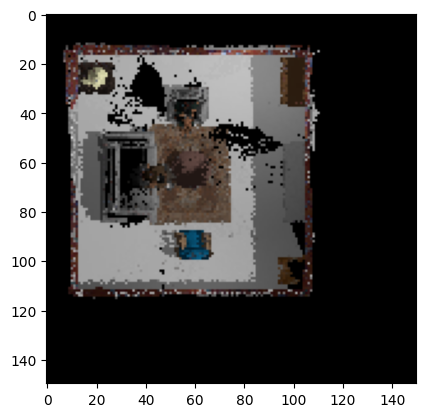

In [381]:
import matplotlib.pyplot as plt
plt.imshow(color_top_down)

Top-k similar grid cells:
max similarity: 96.646484375
min similarity: 0.0


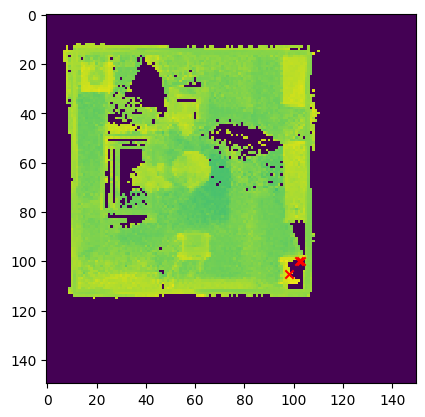

In [382]:
query = "a metal white cabinet"
query_token = clip.tokenize([query]).to(device)
with torch.no_grad():
    query_feat = clip_model.encode_text(query_token)
    # print('quer feat norm:', query_feat.norm(dim=-1))
    # query_feat = query_feat / query_feat.norm(dim=-1, keepdim=True)
query_feat = query_feat.cpu().numpy()   
similarity = grid @ query_feat.T

# get top-k similarity and visualize
top_k = 3
top_k_indices = np.argsort(similarity, axis=None)[-top_k:]
top_k_coords = np.unravel_index(top_k_indices, similarity.shape)
print("Top-k similar grid cells:")
plt.scatter(top_k_coords[1], top_k_coords[0], c='red', marker='x')
# compute softmax similarity
# similarity = np.exp(similarity) / (np.exp(similarity).sum() + 1e-8)
# similarity = similarity / (np.linalg.norm(grid, axis=2) * np.linalg.norm(query_feat) + 1e-8)

plt.imshow(similarity, cmap='viridis', interpolation='nearest')
print(f'max similarity: {similarity.max()}')
print(f'min similarity: {similarity.min()}')

Lower left corner of the free space: x=1.95 m, y=3.35 m
1


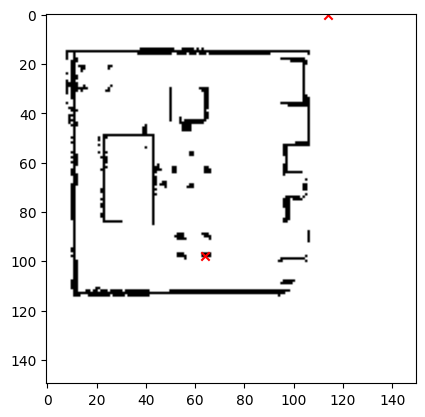

In [422]:
plt.imshow(obstacles, cmap='gray')
plt.scatter([64], [98], c='red', marker='x')
# get the indices of lower left corner where value obstacle[y, x] == 0
x_is, y_is = np.where(obstacles == 0)

y = y_is.min()
x  = x_is.max()

plt.scatter([x], [0], c='red', marker='x')
# get the x and y in meters for x,y with 0 at 75, 75
x_m = (x - 75) * cs
y_m = (75 - y) * cs
print(f"Lower left corner of the free space: x={x_m:.2f} m, y={y_m:.2f} m")
print(obstacles[x, y])

In [421]:
from utils.clip_mapping_utils import grid_id2pos
x, y = grid_id2pos(150, 0.05, 64, 98)
x,y

(-0.55, -1.1500000000000001)

tensor([[49406,   320,  4269, 49407,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0]], device='cuda:0',
       dtype=torch.int32)
(150, 150, 512)
Top-k similar grid cells after loading:
(array([ 96,  96, 114]), array([64, 57, 61]), array([0, 0, 0]))


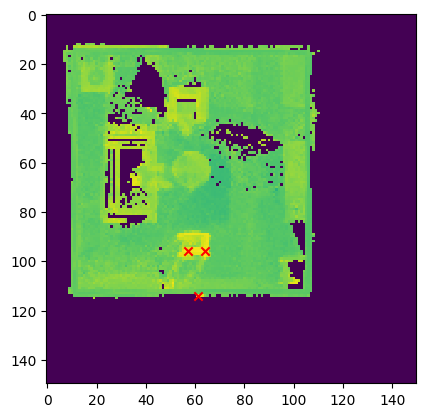

In [420]:
query = "a chair"
query_token = clip.tokenize([query]).to(device)
print(query_token)
with torch.no_grad():
    query_feat = clip_model.encode_text(query_token)
    # print('quer feat norm:', query_feat.norm(dim=-1))
    # query_feat = query_feat / query_feat.norm(dim=-1, keepdim=True)
query_feat = query_feat.cpu().numpy()   
# load the saved grid and query again
loaded_grid = np.load(grid_save_path)
print(loaded_grid.shape)
similarity = loaded_grid @ query_feat.T
top_k_indices = np.argsort(similarity, axis=None)[-top_k:]
top_k_coords = np.unravel_index(top_k_indices, similarity.shape)
print("Top-k similar grid cells after loading:")
print(top_k_coords)
plt.scatter(top_k_coords[1], top_k_coords[0], c='red', marker='x')
plt.imshow(similarity, cmap='viridis', interpolation='nearest') 